# 01 - EDA et preprocessing

Notebook d'exploration des donnees et de preparation du pipeline de preprocessing.

CSV trouves: 2
Images trouvees: 12811


,Case ID,Sex
0,4360,M
1,4361,M
2,4362,M
3,4363,M
4,4364,M


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Case ID,200.0,NaN,NaN,NaN,4459.5,57.879185,4360.0,4409.75,4459.5,4509.25,4559.0
Sex,200,2,M,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN


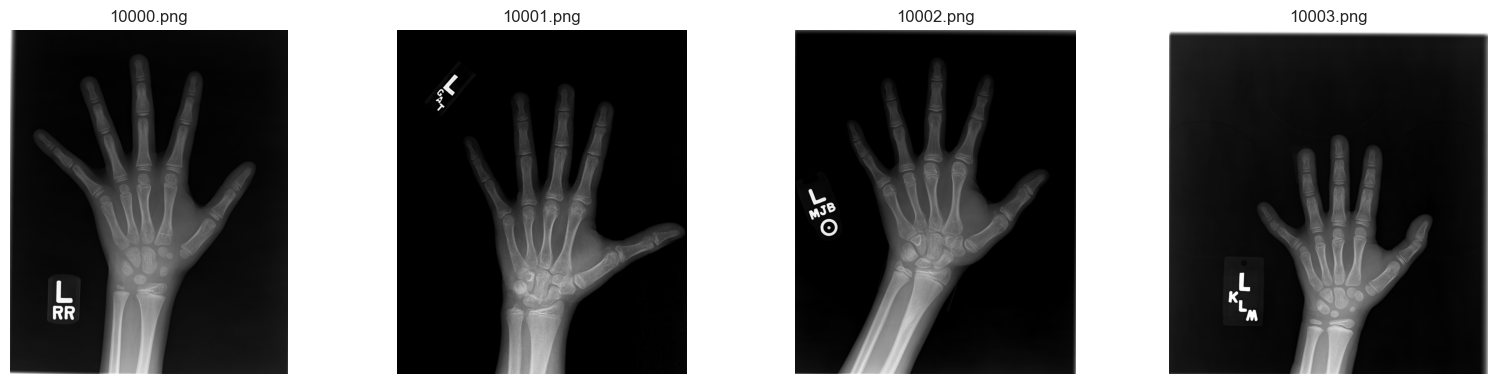

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

ROOT_DIR = Path.cwd().parents[0]
DATA_DIR = ROOT_DIR / 'data'


def find_dataset_files(base_dir: Path):
    csv_files = list(base_dir.rglob('*.csv'))
    image_files = list(base_dir.rglob('*.png')) + list(base_dir.rglob('*.jpg')) + list(base_dir.rglob('*.jpeg'))
    return csv_files, image_files


def load_metadata(csv_path: Path):
    if not csv_path.exists():
        raise FileNotFoundError(f'Metadata introuvable: {csv_path}')
    return pd.read_csv(csv_path)


def infer_target_column(df: pd.DataFrame):
    for column in ['bone_age', 'age', 'label']:
        if column in df.columns:
            return column
    return None


def summarize_dataframe(df: pd.DataFrame):
    display(df.head())
    display(df.describe(include='all').T)


def plot_target_distribution(df: pd.DataFrame, target_column: str):
    fig, ax = plt.subplots()
    sns.histplot(df[target_column], kde=True, bins=30, ax=ax)
    ax.set_title('Distribution de la cible')
    ax.set_xlabel(target_column)
    plt.show()


def preview_images(paths, n=6):
    if not paths:
        print('Aucune image trouvee pour l’aperçu.')
        return
    sample_paths = paths[:n]
    fig, axes = plt.subplots(1, len(sample_paths), figsize=(4 * len(sample_paths), 4))
    axes = np.atleast_1d(axes)
    for axis, image_path in zip(axes, sample_paths):
        image = Image.open(image_path)
        axis.imshow(image, cmap='gray')
        axis.set_title(image_path.name)
        axis.axis('off')
    plt.tight_layout()
    plt.show()


csv_files, image_files = find_dataset_files(DATA_DIR)
print(f'CSV trouves: {len(csv_files)}')
print(f'Images trouvees: {len(image_files)}')

if csv_files:
    metadata = load_metadata(csv_files[0])
    summarize_dataframe(metadata)
    target_column = infer_target_column(metadata)
    if target_column is not None and np.issubdtype(metadata[target_column].dtype, np.number):
        plot_target_distribution(metadata, target_column)

preview_images(image_files, n=4)